In [216]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad
from scipy.optimize import brentq


In [28]:
def magnitude(r: np.array) -> float:
    squared = 0
    for _, e in enumerate(r):
        squared += e*e
    
    return np.sqrt(squared)

def cross2d(r1: np.array, r2: np.array) -> float:
    return r1[0] * r2[1] - r1[1] * r2[0]

In [243]:
G = 1
dt = 0.01
steps = 25000

epsilon = 0.0001

m1 = 5
m2 = 1
p_initial_m1 = np.array([1, 0])
p_initial_m2 = np.array([-1, 0])
v_initial_m1 = np.array([0, 1])
v_initial_m2 = np.array([0, -1])

M = m1+m2
mu = (m1*m2) / M

r_i = p_initial_m1 - p_initial_m2
v_dot_i = v_initial_m1 - v_initial_m2
R_com_i = (p_initial_m1 * m1 + p_initial_m2 * m2) / M
V_com_i = (v_initial_m1 * m1 + v_initial_m2 * m2) / M

r_mag_i = magnitude(r_i)
radial_speed = np.dot(r_i, v_dot_i) / r_mag_i
L_com = mu * (r_i[0] * v_dot_i[1] - r_i[1] * v_dot_i[0])

def Veff(r_mag):
    if r_mag == 0:
        raise ZeroDivisionError
    return np.dot(L_com, L_com) / (2 * mu * r_mag**2) - (G*m1*m2 / r_mag)

def dVeff_dr(r_mag):
    return -np.dot(L_com, L_com) / (mu * r_mag**3) + G * m1 * m2 / r_mag**2

Veff_i = Veff(r_mag_i)
E = 1/2 * mu * radial_speed**2 + Veff_i
print("E:", E)
print("Veff_i:", Veff_i)

r_critical = np.dot(L_com, L_com) / mu * 1 / (G * m1 * m2)
# r_critical should be equivalent to brentq(dVeff_dr, epsilon, 100)

E: -0.8333333333333333
Veff_i: -0.8333333333333333


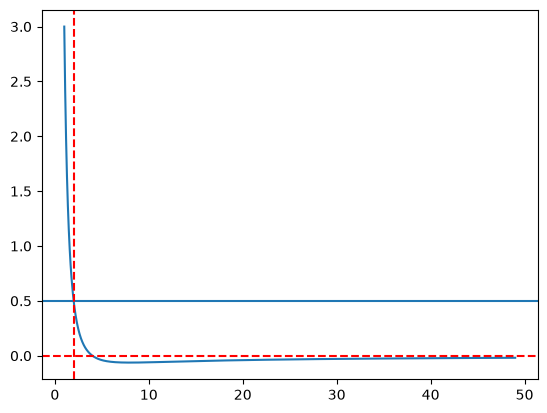

In [218]:
import matplotlib.pyplot as plt

vals = np.linspace(1, 49, 1000)

plt.plot(vals, [Veff(x) for x in vals])
plt.axhline(E)
plt.axhline(0, ls='--', c='r')
plt.axvline(r_mag_i, ls='--', c='r')

In [244]:
#identify radial turning points (where E = Veff)

def radial_kinetic_energy(r_mag):
    return E - Veff(r_mag)

def turning_points():
    inner_bound = r_critical / 2
    while radial_kinetic_energy(inner_bound) > 0:
        inner_bound /= 2
        
    inner = brentq(radial_kinetic_energy, inner_bound, r_critical)
    
    if E >= 0:
        return {
            "inner": inner,
            "outer": None
        }
        
    outer_bound = r_critical * 2
    while radial_kinetic_energy(outer_bound) > 0:
        outer_bound *= 2
        
    outer = brentq(radial_kinetic_energy, r_critical, outer_bound)
        
    return {
        "inner": inner, 
        "outer": outer
    }

In [246]:
def initial_direction():
    
    direction = np.dot(v_dot_i, r_i)
    if direction == 0:
        return -dVeff_dr(r_mag_i)
    
    return np.sign(direction)

def direction(tp, r_mag):
    if tp["outer"] == None:
        #determine from initial direction
        return initial_direction()
    if r_mag < tp["outer"] and r_mag > tp["inner"]:
        return 1
    
    if r_mag == tp["outer"] or r_mag == tp["inner"]:
        return -dVeff_dr(r_mag)
        

In [279]:
tp = turning_points()

def radial_speed(r_mag):
    if E - Veff(r_mag) < 0:
        print("sqrt value", 2 / mu * (E - Veff(r_mag)))
        raise ValueError
    return np.sqrt(2 / mu * (E - Veff(r_mag)))


def dt_dr(r_mag):
    #need to incorporate direction somehow
    dir = direction(tp, r_mag)
    return dir * 1 / radial_speed(r_mag)

def integrand(r_initial_mag: float, r_final_mag: float):
    I, _ = quad(dt_dr, r_initial_mag, r_final_mag)
    return I

def radius_at_time(t):
    half_period = integrand(tp["inner"], tp["outer"])

    t_to_rmin_i = integrand(r_mag_i, tp["inner"])
    t_since_rmin = t - t_to_rmin_i
    curr_cycle = t_since_rmin % (2 * half_period)
    if curr_cycle > half_period:
        return brentq(lambda r: integrand(tp["inner"], r) - (2 * half_period - curr_cycle), tp["inner"], tp["outer"])
    return brentq(lambda r: integrand(tp["inner"], r) - curr_cycle, tp["inner"], tp["outer"])

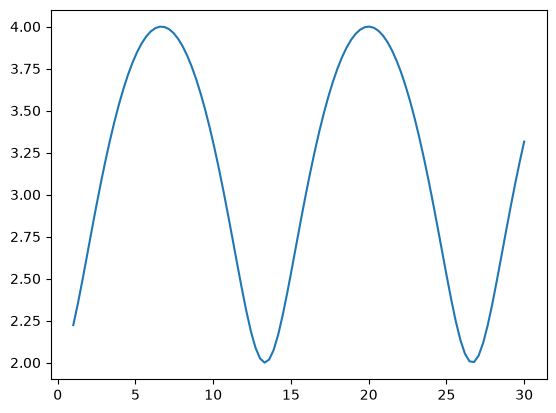

In [280]:
t_values = np.linspace(1, 30, 100)
y_data = [radius_at_time(t) for t in t_values]
plt.plot(t_values, y_data)

In [148]:
integrand(5)

2.7430047547241427